In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE

# Load dataset
df = pd.read_csv('creditcard.csv')

# Display the first few rows
df.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


Class
0    284315
1    284315
Name: count, dtype: int64


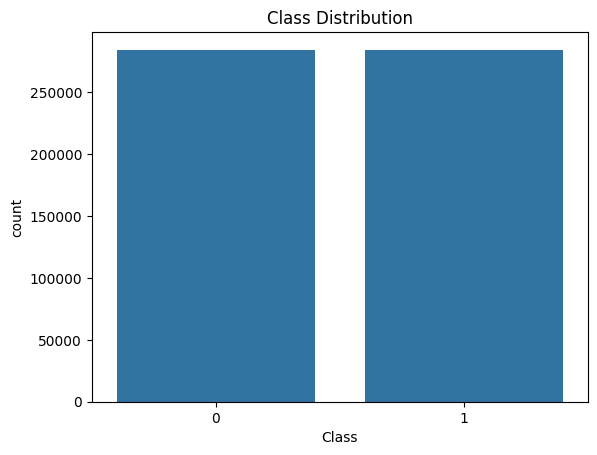

In [2]:
# Checking the class distribution
print(df['Class'].value_counts())

# Plot the class distribution
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.show()


In [3]:
# Define the feature matrix (X) and the target variable (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Apply SMOTE to handle the class imbalance
smote = SMOTE(sampling_strategy='minority')
X_sm, y_sm = smote.fit_resample(X, y)

# Checking the new class distribution
print("After SMOTE:", y_sm.value_counts())


After SMOTE: Class
0    284315
1    284315
Name: count, dtype: int64


In [4]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_sm, y_sm, test_size=0.3, random_state=42)

print(f"Training set size: {X_train.shape}, Test set size: {X_test.shape}")


Training set size: (398041, 30), Test set size: (170589, 30)


In [5]:
scaler = StandardScaler()

# Scale training and testing sets
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [6]:
# Initialize the SVM model with a linear kernel
svm_model = SVC(kernel='linear')

# Train the model
svm_model.fit(X_train, y_train)


SVC(kernel='linear')

Accuracy: 99.88%
Confusion Matrix:
 [[85077    72]
 [  133 85307]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85149
           1       1.00      1.00      1.00     85440

    accuracy                           1.00    170589
   macro avg       1.00      1.00      1.00    170589
weighted avg       1.00      1.00      1.00    170589



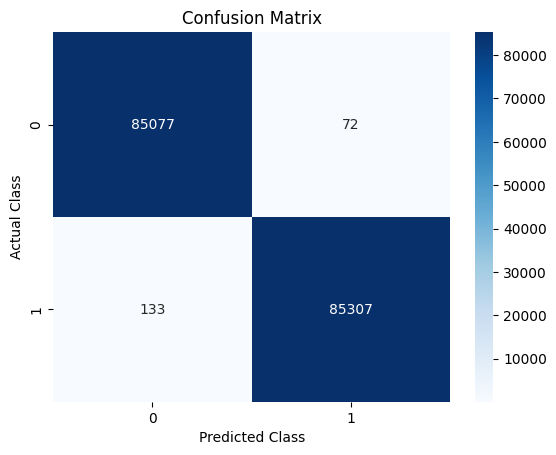

In [7]:
# Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# Classification Report
print(classification_report(y_test, y_pred))

# Plotting the Confusion Matrix
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameters for tuning
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['linear', 'rbf']
}

# Initialize GridSearchCV
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2)
grid.fit(X_train, y_train)

# Best hyperparameters
print(f"Best Parameters: {grid.best_params_}")

# Evaluate with the best model
y_pred_best = grid.predict(X_test)
print(f"Best Accuracy: {accuracy_score(y_test, y_pred_best) * 100:.2f}%")




Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=  57.6s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=  57.8s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=  59.9s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time= 1.0min
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time= 1.0min
